## 1. Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load Data
data = load_breast_cancer()
pd.set_option('display.max_columns', None)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## 2. EDA

(569, 31)
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   

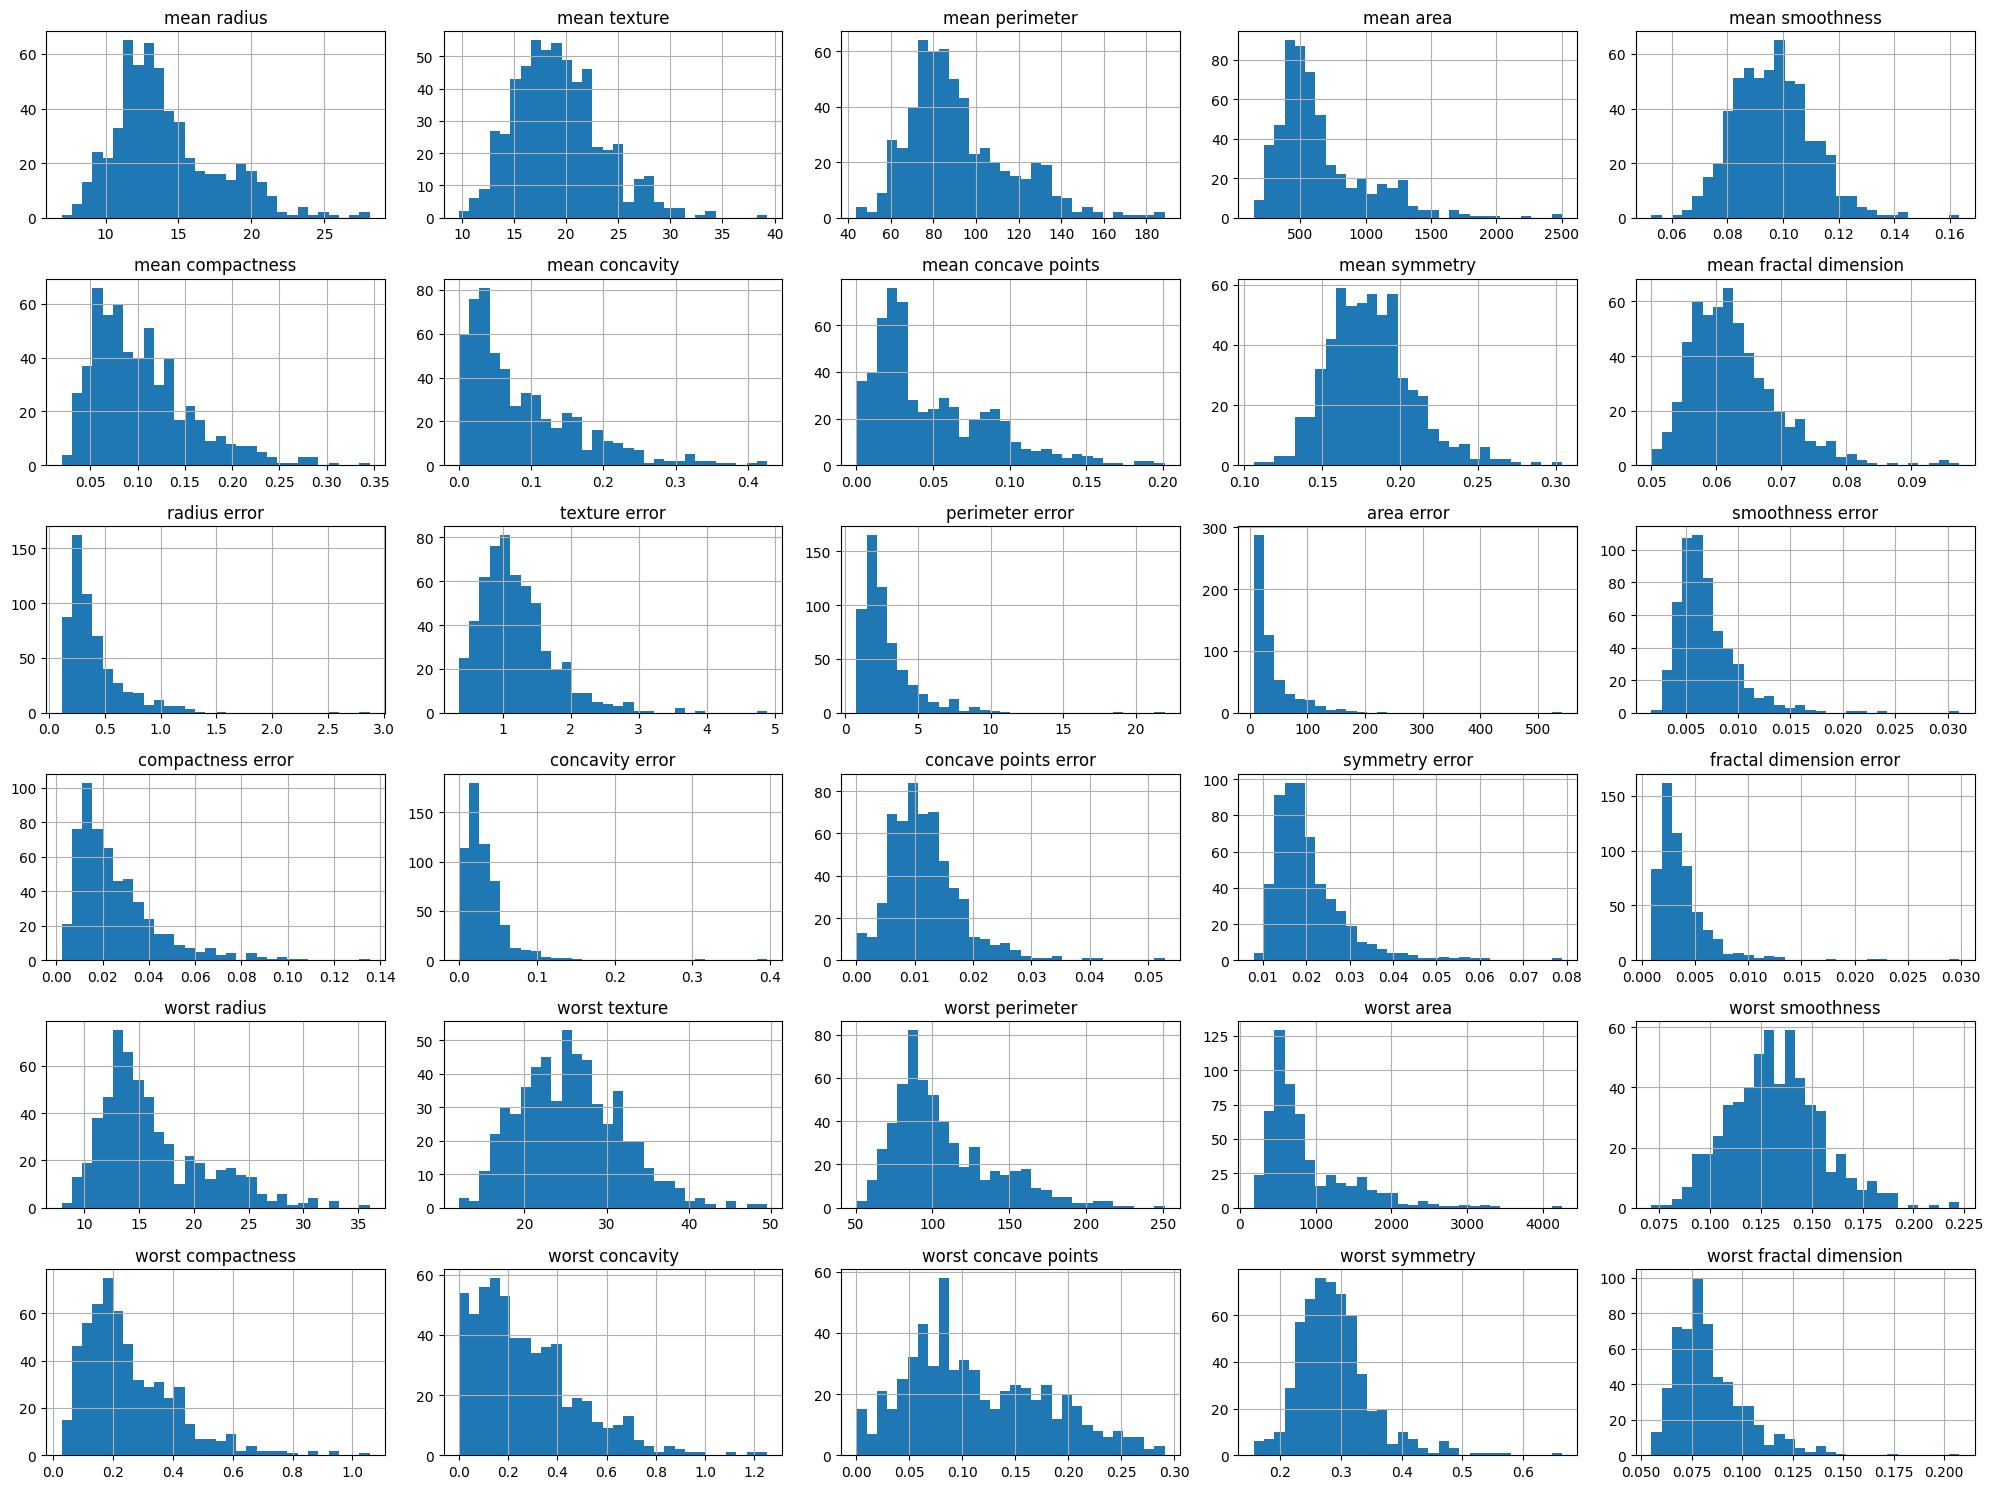

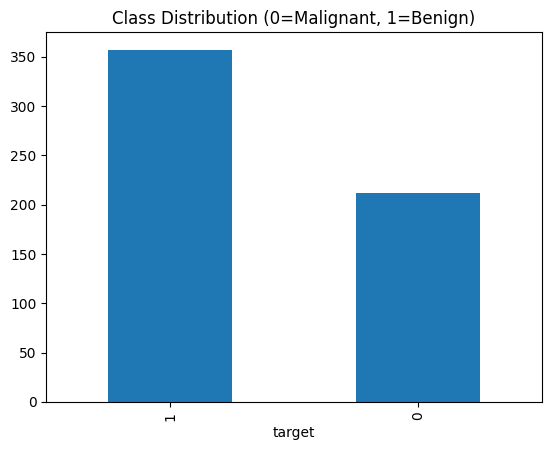

In [20]:
print(df.shape)
print(df.describe())
print(df.isnull().sum())
print(df['target'].value_counts())

df.drop('target', axis=1).hist(bins=30, figsize=(20,15))
plt.tight_layout()
plt.show()

df['target'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0=Malignant, 1=Benign)')
plt.show()

In [21]:
# Cap the skewed columns
skewed_cols = [
    'radius error', 'perimeter error', 'area error', 'smoothness error',
    'compactness error', 'concavity error', 'concave points error',
    'fractal dimension error', 'worst area', 'worst compactness', 'worst concavity',
]
for col in skewed_cols:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

for col in skewed_cols:
    print(f"{col}: mean={df[col].mean():.3f}, median={df[col].median():.3f}")

radius error: mean=0.400, median=0.324
perimeter error: mean=2.825, median=2.287
area error: mean=38.863, median=24.530
smoothness error: mean=0.007, median=0.006
compactness error: mean=0.025, median=0.020
concavity error: mean=0.031, median=0.026
concave points error: mean=0.012, median=0.011
fractal dimension error: mean=0.004, median=0.003
worst area: mean=875.813, median=686.500
worst compactness: mean=0.253, median=0.212
worst concavity: mean=0.271, median=0.227


In [22]:
df['area error'] = np.log1p(df['area error'])
print(f"area error after log: mean={df['area error'].mean():.3f}, median={df['area error'].median():.3f}")

area error after log: mean=3.416, median=3.240


In [23]:
# 3. Data preparation no scaling needed for tree-based models
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3. Decision Tree From scratch

In [24]:
class Node:
  def __init__(self, feature = None, threshold = None, left = None, right = None, *, value = None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value

  def is_leaf(self):
    return self.value is not None

In [33]:
class DecisionTreeScratch:
  def __init__(self, max_depth = 4, min_samples_split = 2, min_samples_leaf = 1, max_features = None):
    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
    self.min_samples_leaf = min_samples_leaf
    self.max_features = max_features
    self.root = None

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    self.root = self._build_tree(X, y, depth = 0)

  def _build_tree(self, X, y, depth):
    n_samples, n_features = X.shape
    n_labels = len(np.unique(y))

    if(depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
      return Node(value = self._majority_class(y))

    best_feature, best_threshold, best_gain = self._best_split(X, y, n_features)

    if best_feature is None or best_gain <= 0:
      return Node(value = self._majority_class(y))

    left_idx, right_idx = self._split(X[:, best_feature], best_threshold)

    if len(left_idx) < self.min_samples_leaf or len(right_idx) < self.min_samples_leaf:
      return Node(value = self._majority_class(y))

    left_child = self._build_tree(X[left_idx], y[left_idx], depth + 1)
    right_child = self._build_tree(X[right_idx], y[right_idx], depth + 1)

    return Node(feature = best_feature, threshold = best_threshold, left = left_child, right = right_child)


  def _best_split(self, X, y, n_features):
    best_gain = -1
    best_feature, best_threshold = None, None
    parent_gini = self._gini(y)

    if self.max_features is not None:
      feature_indices = np.random.choice(n_features, self.max_features, replace = False)
    else:
      feature_indices = range(n_features)

    for feature_idx in feature_indices:
      thresholds = np.unique(X[:, feature_idx])
      for threshold in thresholds:
        left_idx, right_idx = self._split(X[:, feature_idx], threshold)
        if len(left_idx) == 0 or len(right_idx) == 0:
          continue
        gain = self._information_gain(y, left_idx, right_idx, parent_gini)
        if gain > best_gain:
          best_gain = gain
          best_feature = feature_idx
          best_threshold = threshold
    return best_feature, best_threshold, best_gain



  def _split(self, feature_column, threshold):
    left_idx = np.argwhere(feature_column <= threshold).flatten()
    right_idx = np.argwhere(feature_column > threshold).flatten()
    return left_idx, right_idx

  def _gini(self, y):
    if len(y) == 0:
      return 0
    proportions = np.bincount(y) / len(y)
    return 1 - np.sum(proportions ** 2)

  def _information_gain(self, y, left_idx, right_idx, parent_gini):
    n = len(y)
    n_left, n_right = len(left_idx), len(right_idx)
    gini_left = self._gini(y[left_idx])
    gini_right = self._gini(y[right_idx])
    weighted_gini = (n_left / n) * gini_left + (n_right / n) * gini_right
    return parent_gini - weighted_gini

  def _majority_class(self, y):
    return np.bincount(y).argmax()

  def predict(self, X):
    X = np.array(X)
    return np.array([self._traverse(x, self.root) for x in X])

  def _traverse(self, x, node):
    if node.is_leaf():
      return node.value
    if x[node.feature] <= node.threshold:
      return self._traverse(x, node.left)
    return self._traverse(x, node.right)

In [26]:
# Fit custom Decision Tree
tree_scratch = DecisionTreeScratch(max_depth=4, min_samples_split=2, min_samples_leaf=1)
tree_scratch.fit(X_train, y_train)

y_pred_scratch = tree_scratch.predict(X_test)
y_pred_train_scratch = tree_scratch.predict(X_train)

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree_sklearn = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_sklearn.fit(X_train, y_train)

y_pred_sklearn = tree_sklearn.predict(X_test)
y_pred_train_sklearn = tree_sklearn.predict(X_test) if False else tree_sklearn.predict(X_train)

## 4. Comparing our custom Decision Tree with sklearn results

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== Custom Decision Tree ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_scratch):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_scratch):.4f}")
print()
print(classification_report(y_test, y_pred_scratch, target_names=['Malignant', 'Benign']))

=== Custom Decision Tree ===
Train Accuracy: 0.9868
Test Accuracy:  0.9386

              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        42
      Benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [29]:
print("=== Sklearn Decision Tree ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_sklearn):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_sklearn):.4f}")
print()
print(classification_report(y_test, y_pred_sklearn, target_names=['Malignant', 'Benign']))

=== Sklearn Decision Tree ===
Train Accuracy: 0.9868
Test Accuracy:  0.9386

              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        42
      Benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



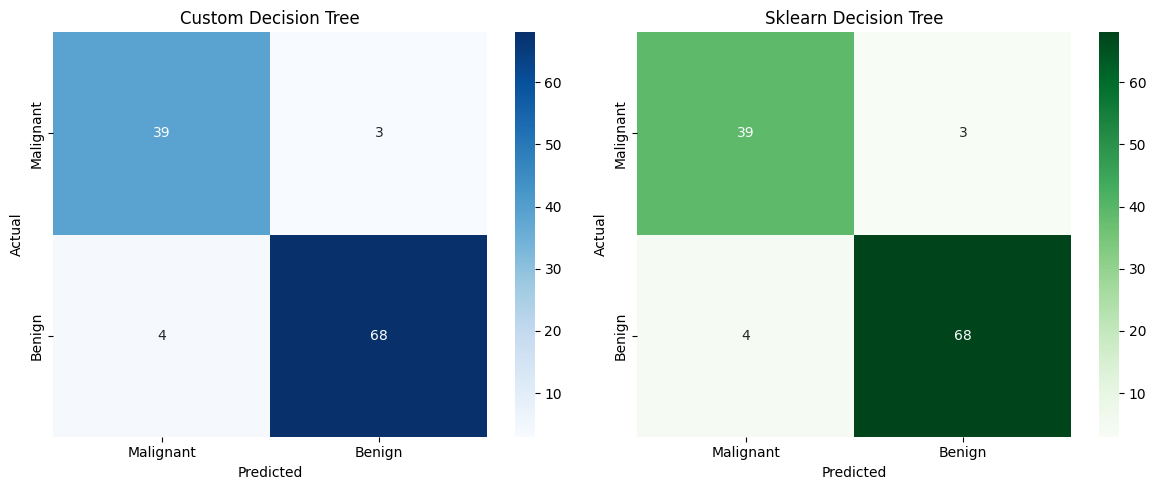

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_scratch = confusion_matrix(y_test, y_pred_scratch)
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[0].set_title('Custom Decision Tree')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[1].set_title('Sklearn Decision Tree')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

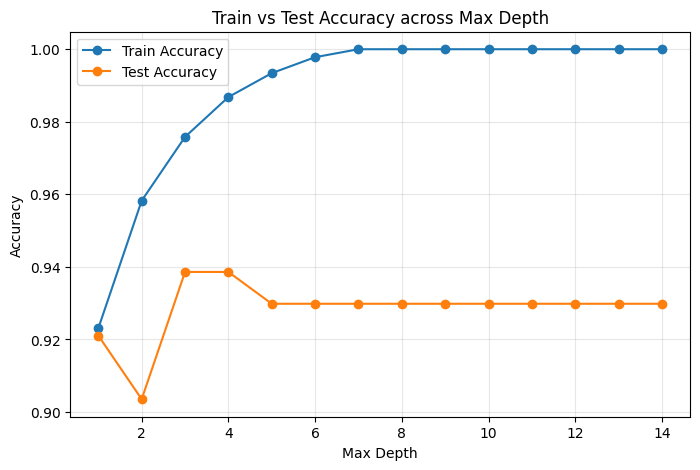

In [31]:
depths = range(1, 15)
train_accs, test_accs = [], []

for d in depths:
    t = DecisionTreeScratch(max_depth=d)
    t.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy')
plt.plot(depths, test_accs, marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across Max Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. RandomForest from Scratch

In [37]:
class RandomForestScratch:
  def __init__(self, n_trees = 100, max_depth = 4, min_samples_split = 2, min_samples_leaf = 1, max_features = None):
    self.n_trees = n_trees
    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
    self.min_samples_leaf = min_samples_leaf
    self.max_features = max_features
    self.trees = []

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape

    max_feat = self.max_features
    if max_feat is None:
      max_feat = int(np.sqrt(n_features))

    self.trees = []
    for _ in range(self.n_trees):
      sample_idx = np.random.choice(n_samples, size = n_samples, replace = True)
      X_sample, y_sample = X[sample_idx], y[sample_idx]

      tree = DecisionTreeScratch(max_depth = self.max_depth, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, max_features=max_feat)
      tree.fit(X_sample, y_sample)
      self.trees.append(tree)

  def predict(self, X):
    X = np.array(X)
    tree_preds = np.array([tree.predict(X) for tree in self.trees])
    tree_preds = tree_preds.T

    return np.array([np.bincount(sample_votes).argmax() for sample_votes in tree_preds])

In [38]:
forest_scratch = RandomForestScratch(n_trees=100, max_depth=4)
forest_scratch.fit(X_train, y_train)

y_pred_forest_scratch = forest_scratch.predict(X_test)
y_pred_train_forest_scratch = forest_scratch.predict(X_train)

In [39]:
from sklearn.ensemble import RandomForestClassifier

forest_sklearn = RandomForestClassifier(n_estimators = 100, max_depth = 4, random_state = 42)
forest_sklearn.fit(X_train, y_train)

y_pred_forest_sklearn = forest_sklearn.predict(X_test)
y_pred_train_forest_sklearn = forest_sklearn.predict(X_train)

## 6. Comparing our custom RandomForest with SK learn's RF

In [40]:
print("=== Custom Random Forest ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_forest_scratch):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_forest_scratch):.4f}")
print()
print(classification_report(y_test, y_pred_forest_scratch, target_names=['Malignant', 'Benign']))

print("=== Sklearn Random Forest ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train_forest_sklearn):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_forest_sklearn):.4f}")
print()
print(classification_report(y_test, y_pred_forest_sklearn, target_names=['Malignant', 'Benign']))

=== Custom Random Forest ===
Train Accuracy: 0.9934
Test Accuracy:  0.9474

              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

=== Sklearn Random Forest ===
Train Accuracy: 0.9934
Test Accuracy:  0.9561

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



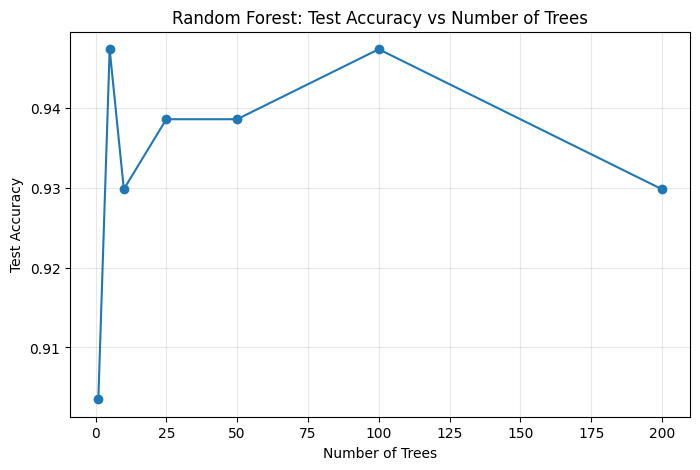

In [41]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200]
test_accs = []

for n in n_trees_list:
    f = RandomForestScratch(n_trees=n, max_depth=4)
    f.fit(X_train, y_train)
    test_accs.append(accuracy_score(y_test, f.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(n_trees_list, test_accs, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Test Accuracy vs Number of Trees')
plt.grid(alpha=0.3)
plt.show()

## Summary

### Decision Tree
Implemented a binary classification Decision Tree from scratch using NumPy,
using Gini impurity to evaluate splits and recursive greedy splitting to
build the tree top-down.

**Key design choices:**
- Gini impurity (not entropy) as the splitting criterion
- Stopping conditions: max_depth, node purity, min_samples_split, min_samples_leaf
- No feature scaling  tree splits are threshold comparisons on raw values,
  so scaling has zero effect on resulting splits

**Results (max_depth=4):**
| Model | Test Accuracy |
|---|---|
| Custom Decision Tree | 93.86% |
| Sklearn Decision Tree | 93.86% |

Confusion matrices were identical between custom and sklearn implementations
(39 / 3 / 4 / 68) the custom tree produced the exact same predictions,
sample for sample, confirming the split-search and recursion logic are
mechanically correct.

### Random Forest
Built as a wrapper around the Decision Tree class no duplicated tree logic.
Two sources of randomness were added to de-correlate trees:
- **Bagging**: each tree trains on a bootstrap sample (rows sampled with
  replacement, same size as original training set)
- **Random feature subsets**: each split only considers `sqrt(n_features)`
  randomly chosen features instead of all of them, forcing trees to diverge
  structurally even when one feature dominates

**Results (n_trees=100, max_depth=4):**
| Model | Train Accuracy | Test Accuracy |
|---|---|---|
| Custom Random Forest | 99.34% | 94.74% |
| Sklearn Random Forest | 99.34% | 95.61% |

The forest outperformed the single tree on test accuracy (94.74% vs 93.86%),
consistent with ensemble theory. The small remaining gap vs sklearn (one
misclassification) is explained by differing RNG sequences for bootstrap
sampling and feature subset selection not an implementation flaw.

### Key Learnings
- Tree-based models are scale-invariant: splits depend only on value order,
  not magnitude, so StandardScaler is unnecessary preprocessing for trees
- Information Gain = Gini(parent) - WeightedGini(children); weighting by
  child size is essential, otherwise a split can look artificially good by
  isolating a single outlier into its own pure node
- A single deep tree overfits (train accuracy approaches 100% while test
  accuracy lags); max_depth is the primary lever against this
- Bagging alone often isn't enough to decorrelate trees if one feature
  dominates, every bootstrap sample still picks it at the root. Random
  feature subsets at each split are what actually force structurally
  different trees
- Accuracy on a small test set (114 samples) is a chunky, noisy metric;
  evaluating ensemble size effects requires averaging over multiple random
  seeds, not a single run, to see the real variance-reduction trend